In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report 

In [120]:
df=pd.read_csv('penguins_size.csv')  #데이터프레임으로 파일을 읽어옴/깨지면 인코딩해줘야함

In [121]:
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [122]:
print(df.shape)

(344, 7)


In [123]:
df.info()  #결측치 개수랑 열별 타입이 중요

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [124]:
df.describe()   #수치데이터들만 나옴

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [125]:
df['sex'].unique()  #어레이(배열)로 돌려줌/nan은 결측치라 괜찮은데 .이라는 잘못된 값이 있음

array(['MALE', 'FEMALE', nan, '.'], dtype=object)

In [126]:
df[df['sex']=='.']  #.이 들어간 행을 찾아내기

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [127]:
df.drop(336, inplace=True)  #행으로 날리기/컬럼은 df.drop(columns=['칼럼'])

In [128]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [136]:
features = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'  ]#결측치를 평균 값으로 채운거/채워야하는 컬럼을 리스트로 변수에 묶어 원큐에 처리
df[features] = df[features].fillna(df[features].mean())

In [137]:
df.dropna(subset=['sex'], inplace=True)

In [138]:
df.shape

(333, 7)

In [139]:
df.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [140]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


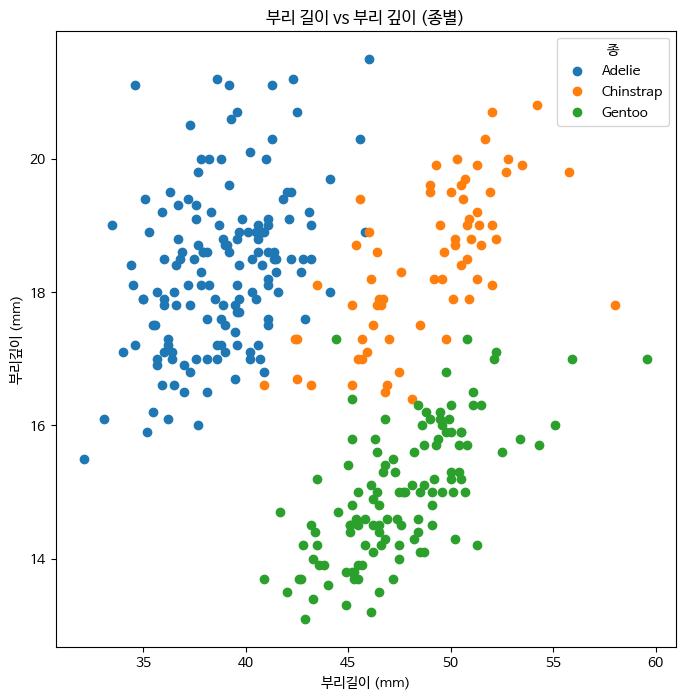

In [153]:
plt.rc('font', family="NanumBarunGothic")
plt.figure(figsize=(8, 8))
for species, g in df.groupby('species'):
    plt.scatter(g['culmen_length_mm'], g['culmen_depth_mm'], label=species)

plt.xlabel('부리길이 (mm)')
plt.ylabel('부리깊이 (mm)')
plt.title('부리 길이 vs 부리 깊이 (종별)')
plt.legend(title='종')
plt.show()

In [148]:
X = df[features]   #기준값(x)와 결과값(y)로 나눈거-데이터프레임으로 받았을때 가장 중요한 절차
y = df['species']

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"훈련 데이터: {X_train.shape[0]}개,  {y_train.shape[0]}개")
print(f"테스트 데이터: {X_test.shape[0]}개, {y_test.shape[0]}개")

훈련 데이터: 249개,  249개
테스트 데이터: 84개, 84개


In [161]:
knn = KNeighborsClassifier(n_neighbors=3)  #홀수로 잡아야 개수가 딱 갈려서 짝수로 잡진 않음
knn.fit(X_train, y_train)  #훈련이니 트레이닝 데이터를 먹이고

KNeighborsClassifier(n_neighbors=3)

In [162]:
y_pred = knn.predict(X_test)    #예측(테스트)이니 테스트 데이터를 먹임
print('테스트 세트 예측 값:\n',y_pred)
print('테스트 세트 실제 타킷:\n', y_test)

테스트 세트 예측 값:
 ['Chinstrap' 'Gentoo' 'Adelie' 'Chinstrap' 'Chinstrap' 'Gentoo' 'Gentoo'
 'Adelie' 'Chinstrap' 'Chinstrap' 'Gentoo' 'Adelie' 'Gentoo' 'Adelie'
 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie'
 'Gentoo' 'Chinstrap' 'Adelie' 'Adelie' 'Gentoo' 'Gentoo' 'Chinstrap'
 'Gentoo' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie'
 'Chinstrap' 'Adelie' 'Adelie' 'Adelie' 'Adelie' 'Chinstrap' 'Adelie'
 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Gentoo'
 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Adelie'
 'Gentoo' 'Gentoo' 'Gentoo' 'Adelie' 'Gentoo' 'Gentoo' 'Chinstrap'
 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Gentoo'
 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie'
 'Adelie' 'Adelie' 'Adelie']
테스트 세트 실제 타킷:
 30        Adelie
317       Gentoo
79        Adelie
201    Chinstrap
63        Adelie
         ...    
247       Gentoo
122       Adelie
146       Adelie
182    Chinst

In [165]:
accuracy  = accuracy_scoreknn.score(y_test, y_pred)

print(f'모델 정확도: {acc_test:.4f}, {acc_test:.2%}')

/opt/tljh/user/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


ValueError: could not convert string to float: 'Adelie'